# Semi-supervised Autoencoder (Low-FP / High-TP) – Revised

**AUC = 0.822**

In [26]:

# 0) Imports + settings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ===== USER KNOBS =====
CSV_PATH = "customer_clusters.csv"   # <- change if needed
ID_COL = "customer_id"
LABEL_COL = "label"                     # 1=suspicious, 0=normal, NaN=unlabeled (semi-supervised)
CLUSTER_COL = "cluster"               # cluster id column (0..6); set to None to disable
CLUSTER_K = 7                         # number of clusters (0..6)
MAX_ROWS = None                         # set e.g. 2_000_000 if you want a speed cap
BATCH_SIZE = 1024
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-5

# Categorical hashing dimension (keeps memory bounded)
HASH_DIM = 256

# Threshold control: choose ONE of these constraints (recommended)
MAX_FPR = 0.02          # keep false alarm rate <= 2% on labeled normals
MIN_PRECISION = None    # alternatively set e.g. 0.30 and set MAX_FPR=None

In [27]:

# 1) Load data (optionally sample rows)
df = pd.read_csv(CSV_PATH)

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=RANDOM_SEED)

# Basic sanitation
if LABEL_COL not in df.columns:
    raise ValueError(f"Missing {LABEL_COL} in dataframe.")

print(df.shape)
df[[ID_COL, LABEL_COL]].head()


(61410, 54)


,customer_id,label
0,SYNID0100000167,NaN
1,SYNID0100000431,NaN
2,SYNID0100000485,0.0
3,SYNID0100000539,NaN
4,SYNID0100000932,NaN


In [28]:

frequency_table = df['customer_type'].value_counts()
frequency_table

customer_type
IND    53099
SB      8311
Name: count, dtype: int64

In [29]:

# 2) Build a compact feature matrix (numeric robust + categorical hashing)
#    Key idea: avoid OneHotEncoder dense explosion; hashing keeps a fixed width.

y = df[LABEL_COL]
X = df.drop(columns=[c for c in [ID_COL, LABEL_COL] if c in df.columns], errors="ignore")

# Optional: handle precomputed customer cluster as a small one-hot block
cluster_onehot = None
if 'CLUSTER_COL' in globals() and CLUSTER_COL and (CLUSTER_COL in X.columns):
    # treat cluster as categorical segment (expected 0..CLUSTER_K-1); missing -> -1 bucket
    cl = pd.to_numeric(X[CLUSTER_COL], errors="coerce").fillna(-1).astype(int)

    cluster_onehot = pd.get_dummies(cl, prefix=CLUSTER_COL, dtype=np.float32)

    # Ensure a stable set of columns (important when train/test are split and some clusters are absent)
    expected = [f"{CLUSTER_COL}_{k}" for k in range(int(CLUSTER_K))]
    if (cl == -1).any():
        expected = expected + [f"{CLUSTER_COL}_-1"]
    cluster_onehot = cluster_onehot.reindex(columns=expected, fill_value=np.float32(0.0))

    X = X.drop(columns=[CLUSTER_COL])

# Identify categorical vs numeric
cat_cols = [c for c in X.columns if (str(X[c].dtype) in ["object", "category", "string"])]
num_cols = [c for c in X.columns if c not in cat_cols]

# Keep feature name lists for later interpretation
NUM_COLS = num_cols
CAT_COLS = cat_cols

# Seed normals for fitting scalers/imputers (prevents leakage of anomaly distribution)
seed_normal_mask = (y == 0)
if seed_normal_mask.sum() == 0:
    # fall back to all rows if you truly have no labeled normals
    seed_normal_mask = np.ones(len(df), dtype=bool)

# ----- numeric pipeline (median + robust scaler) -----
num_imputer = SimpleImputer(strategy="median")
scaler = RobustScaler(with_centering=True)

X_num_seed = num_imputer.fit_transform(X.loc[seed_normal_mask, num_cols]) if num_cols else np.zeros((seed_normal_mask.sum(), 0))
scaler.fit(X_num_seed)

X_num_all = num_imputer.transform(X[num_cols]) if num_cols else np.zeros((len(df), 0))
X_num_all = scaler.transform(X_num_all).astype(np.float32)

# ----- categorical hashing (fixed HASH_DIM) -----
# Convert each row's categorical values into "col=value" tokens and hash to dense float32
hasher = FeatureHasher(n_features=HASH_DIM, input_type="string")

def cat_tokens(frame: pd.DataFrame) -> list[list[str]]:
    # each row -> list of tokens
    arr = []
    for _, row in frame.iterrows():
        toks = []
        for c in cat_cols:
            v = row[c]
            if pd.isna(v):
                continue
            toks.append(f"{c}={v}")
        arr.append(toks)
    return arr

if cat_cols:
    # to reduce overhead, cast to string and fill NaNs once
    X_cat = X[cat_cols].astype("string").fillna("")
    X_cat_h = hasher.transform(cat_tokens(X_cat)).toarray().astype(np.float32)
else:
    X_cat_h = np.zeros((len(df), 0), dtype=np.float32)

X_all = np.hstack([X_num_all, X_cat_h]).astype(np.float32)
# Append cluster one-hot (if provided)
if cluster_onehot is not None:
    X_all = np.hstack([X_all, cluster_onehot.to_numpy(dtype=np.float32, copy=False)])

# Build feature names aligned with X_all columns
hash_names = [f"hash_{i}" for i in range(X_cat_h.shape[1])]
feature_names = list(NUM_COLS) + hash_names
if cluster_onehot is not None:
    feature_names = feature_names + list(cluster_onehot.columns)

print("Final feature matrix:", X_all.shape)


c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Final feature matrix: (61410, 311)


In [30]:

# 3) Autoencoder + helpers
class DenoisingAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, bottleneck: int = 32, dropout: float = 0.10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, bottleneck),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

@torch.no_grad()
def recon_error(model, X_np, batch_size=4096):
    device = next(model.parameters()).device
    model.eval()
    errs = np.empty((X_np.shape[0],), dtype=np.float32)
    for i in range(0, X_np.shape[0], batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
        rb = model(xb)
        e = torch.mean((rb - xb) ** 2, dim=1).detach().cpu().numpy().astype(np.float32)
        errs[i:i+batch_size] = e
    return errs

def train_ae_on_normals(X_np, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGHT_DECAY):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = DenoisingAE(input_dim=X_np.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss(reduction="mean")

    # small validation split for early stopping
    X_tr, X_va = train_test_split(X_np, test_size=0.2, random_state=RANDOM_SEED)
    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
    va = torch.tensor(X_va, dtype=torch.float32, device=device)

    best_state = None
    best_va = np.inf
    patience, bad = 6, 0

    for ep in range(1, epochs+1):
        model.train()
        for (xb,) in tr_loader:
            xb = xb.to(device)
            # denoising: add small gaussian noise
            xb_noisy = xb + 0.01 * torch.randn_like(xb)
            opt.zero_grad()
            rb = model(xb_noisy)
            loss = loss_fn(rb, xb)
            loss.backward()
            opt.step()

        # validation
        model.eval()
        with torch.no_grad():
            rv = model(va)
            va_loss = loss_fn(rv, va).item()

        if va_loss < best_va - 1e-6:
            best_va = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        print(f"Epoch {ep:02d} | val_mse={va_loss:.6f} | best={best_va:.6f}")
        if bad >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


In [31]:

# 4) Semi-supervised normal expansion (safe): add only the MOST normal unlabeled points
seed_normal_mask = (y == 0)
unlabeled_mask = y.isna()

X_seed = X_all[seed_normal_mask.values]
X_unlab = X_all[unlabeled_mask.values]

print("Seed normals:", X_seed.shape[0])
print("Unlabeled:", X_unlab.shape[0])

# Step A: train AE on seed normals
ae0 = train_ae_on_normals(X_seed)

# Step B: score unlabeled and add low-error subset as likely normal
if X_unlab.shape[0] > 0:
    unlab_err = recon_error(ae0, X_unlab)
    # add the bottom q% as likely-normal; keep conservative to avoid contaminating
    q = 0.20  # bottom 20% most-normal
    thr = np.quantile(unlab_err, q)
    X_likely_normal = X_unlab[unlab_err <= thr]
    print("Adding likely-normal unlabeled:", X_likely_normal.shape[0])

    X_expanded = np.vstack([X_seed, X_likely_normal]).astype(np.float32)
else:
    X_expanded = X_seed.astype(np.float32)

# Step C: retrain AE on expanded normals
ae = train_ae_on_normals(X_expanded)

# Final AE anomaly score for all customers
ae_score = recon_error(ae, X_all)


Seed normals: 990
Unlabeled: 60410
Epoch 01 | val_mse=142608.078125 | best=142608.078125
Epoch 02 | val_mse=142292.187500 | best=142292.187500
Epoch 03 | val_mse=142006.140625 | best=142006.140625
Epoch 04 | val_mse=141744.218750 | best=141744.218750
Epoch 05 | val_mse=141503.734375 | best=141503.734375
Epoch 06 | val_mse=141274.406250 | best=141274.406250
Epoch 07 | val_mse=141056.546875 | best=141056.546875
Epoch 08 | val_mse=140823.375000 | best=140823.375000
Epoch 09 | val_mse=140560.171875 | best=140560.171875
Epoch 10 | val_mse=140261.718750 | best=140261.718750
Epoch 11 | val_mse=139953.984375 | best=139953.984375
Epoch 12 | val_mse=139626.250000 | best=139626.250000
Epoch 13 | val_mse=139298.421875 | best=139298.421875
Epoch 14 | val_mse=138946.828125 | best=138946.828125
Epoch 15 | val_mse=138570.562500 | best=138570.562500
Epoch 16 | val_mse=138168.343750 | best=138168.343750
Epoch 17 | val_mse=137734.843750 | best=137734.843750
Epoch 18 | val_mse=137280.921875 | best=137280.

In [32]:

# 5) Add a second lightweight detector (IsolationForest) + calibrate to labels
#    Why: AE alone often has weak separation; IF catches different patterns.
iso = IsolationForest(
    n_estimators=200,
    max_samples=256_000 if len(df) > 256_000 else "auto",
    contamination="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_expanded)  # fit on normals/likely-normals
iso_raw = -iso.score_samples(X_all).astype(np.float32)  # higher = more anomalous

# Build score table
scores = pd.DataFrame({
    ID_COL: df[ID_COL].astype(str).values if ID_COL in df.columns else np.arange(len(df)).astype(str),
    "ae_score": ae_score.astype(np.float32),
    "iso_score": iso_raw.astype(np.float32),
})
# Simple rank-based risk_score in [0,1]
scores["risk_score"] = scores[["ae_score","iso_score"]].mean(axis=1).rank(pct=True).astype(np.float32)

# Calibrate combination using labeled subset (supervised on scores only)
labeled_mask = y.notna()
if labeled_mask.sum() > 0 and y[labeled_mask].nunique() > 1:
    X_cal = scores.loc[labeled_mask, ["ae_score","iso_score","risk_score"]].values
    y_cal = y.loc[labeled_mask].astype(int).values

    cal = LogisticRegression(class_weight="balanced", max_iter=2000, solver="lbfgs")
    cal.fit(X_cal, y_cal)

    # calibrated probability as final score (better for TP/FP tradeoff)
    scores["risk_score"] = cal.predict_proba(scores[["ae_score","iso_score","risk_score"]].values)[:, 1].astype(np.float32)
    print("Calibration: OK (LogisticRegression on labeled subset)")
else:
    print("Calibration skipped (need both 0 and 1 labels).")


Calibration: OK (LogisticRegression on labeled subset)


Chosen threshold: 0.869780
TP=4  FP=8  FN=6  TN=982
Precision=0.3333  Sensitivity/Recall=0.4000  FPR=0.0081


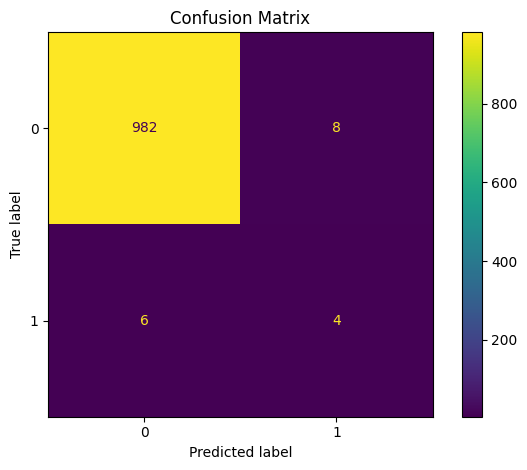

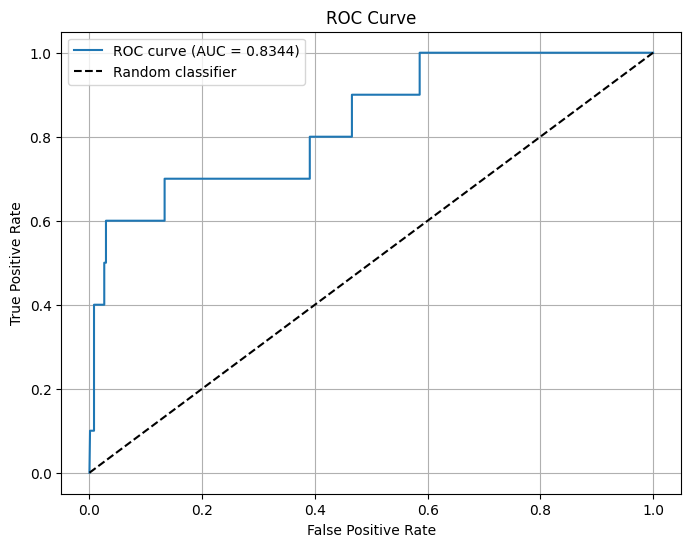

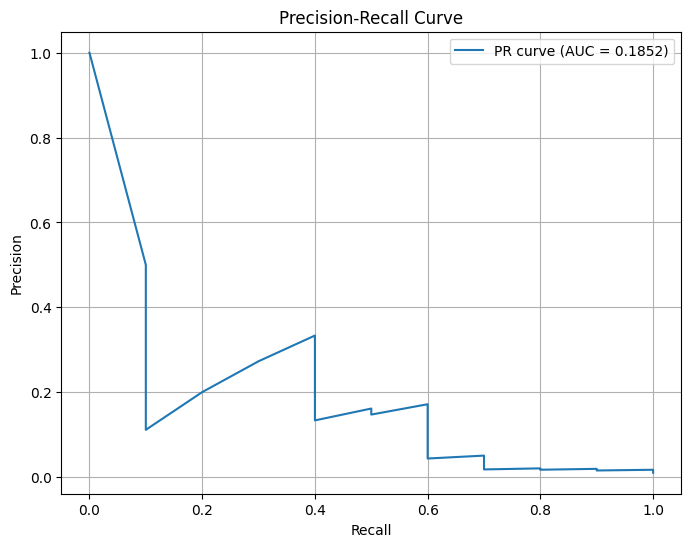

AUC-ROC: 0.8343939393939394
AUC-PR (Average Precision): 0.1745490465569586


,customer_id,ae_score,iso_score,risk_score,predicted_label
0,SYNID0100000167,0.862648,0.411387,0.320831,0
1,SYNID0100000431,0.218470,0.533762,0.390197,0
2,SYNID0100000485,0.081293,0.428658,0.223270,0
3,SYNID0100000539,23.218681,0.653877,0.660232,0
4,SYNID0100000932,21.279638,0.720485,0.727749,0


In [33]:

# 6) Threshold selection: maximize TP subject to a false-alarm constraint
#    Choose threshold on LABELED customers only, then apply to all.
labeled_mask = y.notna()
if labeled_mask.sum() == 0:
    raise ValueError("No labeled rows available to compute confusion matrix / sensitivity.")

y_true = y.loc[labeled_mask].astype(int).values
s = scores.loc[labeled_mask, "risk_score"].values

# Precision-recall curve (good for imbalanced)
prec, rec, thr = precision_recall_curve(y_true, s)
# thr has len = len(prec)-1
thr_full = np.r_[thr, thr[-1] + 1e-12]  # align lengths for convenience

# Utility to compute CM metrics at threshold
def cm_metrics(t):
    yp = (s >= t).astype(int)
    cm = confusion_matrix(y_true, yp, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp/(tp+fp+1e-12)
    recall = tp/(tp+fn+1e-12)        # sensitivity (TPR)
    fpr = fp/(fp+tn+1e-12)
    return tn, fp, fn, tp, precision, recall, fpr, cm

# Search thresholds (use thr from PR curve for speed)
cands = np.unique(thr)
best = None

for t in cands:
    tn, fp, fn, tp, p, r, fpr, cm = cm_metrics(t)
    if MAX_FPR is not None:
        if fpr > MAX_FPR: 
            continue
    if MIN_PRECISION is not None:
        if p < MIN_PRECISION:
            continue
    # objective: maximize TP, then minimize FP as tie-breaker
    key = (tp, -fp, p, r)
    if best is None or key > best[0]:
        best = (key, t, (tn, fp, fn, tp, p, r, fpr, cm))

if best is None:
    # fallback: maximize F2 if constraints are too strict
    beta = 2.0
    best_f = (-1, None, None)
    for t in cands:
        tn, fp, fn, tp, p, r, fpr, cm = cm_metrics(t)
        f2 = (1+beta**2)*p*r/(beta**2*p + r + 1e-12)
        if f2 > best_f[0]:
            best_f = (f2, t, (tn, fp, fn, tp, p, r, fpr, cm))
    chosen_t = best_f[1]
    tn, fp, fn, tp, p, r, fpr, cm = best_f[2]
    print("No threshold met constraints. Falling back to max F2.")
else:
    chosen_t = best[1]
    tn, fp, fn, tp, p, r, fpr, cm = best[2]

print(f"Chosen threshold: {chosen_t:.6f}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Precision={p:.4f}  Sensitivity/Recall={r:.4f}  FPR={fpr:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 8) Plot ROC-AUC curve
from sklearn.metrics import roc_curve

# Assuming y_true and s are still in scope from chunk 6
fpr, tpr, thresholds = roc_curve(y_true, s)
auc = roc_auc_score(y_true, s)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 8) Plot AUC-PR curve
from sklearn.metrics import precision_recall_curve, auc

# Assuming y_true and s are still in scope from chunk 6
precision, recall, thresholds = precision_recall_curve(y_true, s)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

print("AUC-ROC:", roc_auc_score(y_true, s))
print("AUC-PR (Average Precision):", average_precision_score(y_true, s))

# Apply to all customers
scores["predicted_label"] = (scores["risk_score"] >= chosen_t).astype(int)
scores.head()


,Normal (0),Suspicious (1),importance diff
Income Transaction Gap Score,23786,52340960,52317176
Spending-to-Income Ratio,28259,42178444,42150184
Days with Near-Threshold Transactions,16343,19079530,19063186
Customer Cluster 0,384,223567,223183
Transaction Velocity Volatility,625,199180,198554


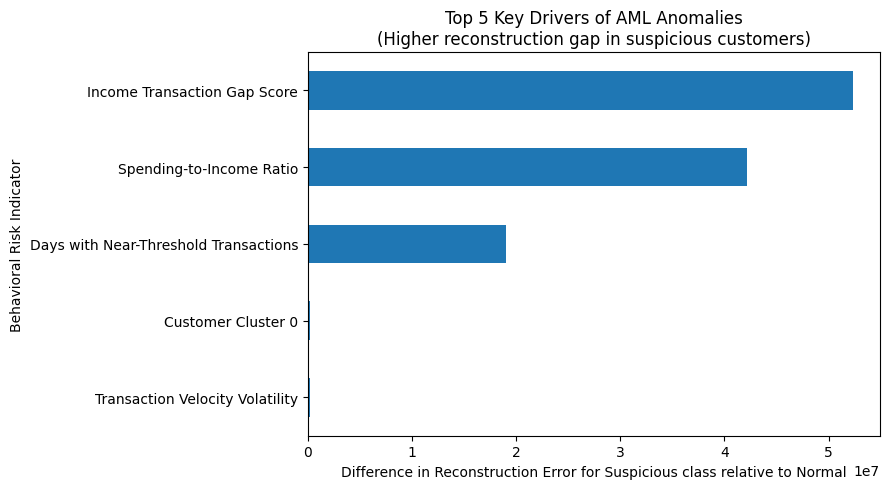

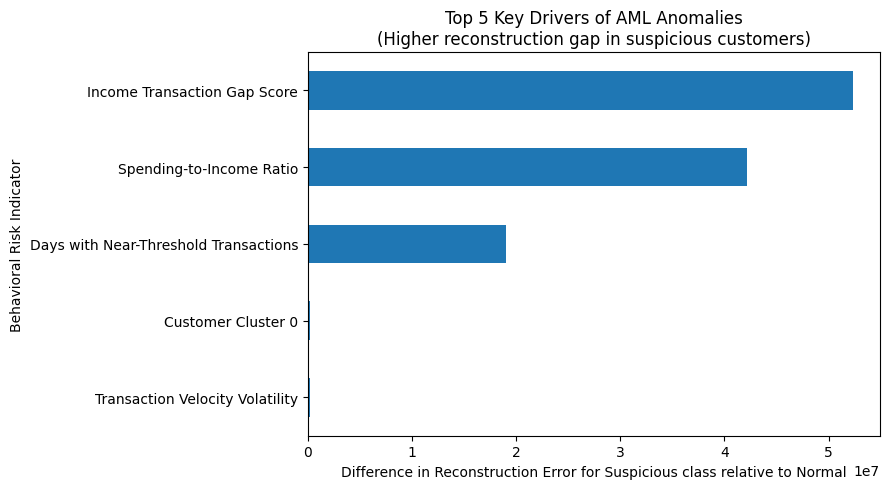

In [49]:
# 6.5) Feature importance for AE (reconstruction-error contribution)
# AML-friendly interpretation:
# - Autoencoders don't have tree-like importance.
# - We explain *which input features drive the anomaly score* by measuring
#   per-feature reconstruction error, and comparing Suspicious (1) vs Normal (0) on labeled customers.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_name_map = {
    "income_transaction_gap_score": "Income Transaction Gap Score",
    "spending_income_ratio": "Spending-to-Income Ratio",
    "struct_days_with_near": "Days with Near-Threshold Transactions",
    "struct_total_near_n": "Total Near-Threshold Transactions",
    "std_velocity": "Transaction Velocity Volatility",
    "cash_value_ratio": "Cash Transaction Ratio",
    "pct_tx_province_mismatch": "Province Mismatch Percentage",
    "pct_tx_city_mismatch": "City Mismatch Percentage",
    "cluster_0": "Customer Cluster 0",
    "cluster_1": "Customer Cluster 1",
    "cluster_2": "Customer Cluster 2",
    "cluster_3": "Customer Cluster 3",
    "cluster_4": "Customer Cluster 4",
    "cluster_5": "Customer Cluster 5",
    "cluster_6": "Customer Cluster 6",
}

# ---- Helper: get reconstructed X (same shape as input) ----
@torch.no_grad()
def recon_matrix(model, X_np, batch_size=4096):
    device = next(model.parameters()).device
    model.eval()
    outs = []
    for i in range(0, len(X_np), batch_size):
        xb = torch.from_numpy(X_np[i:i+batch_size]).to(device)
        xhat = model(xb).cpu().numpy()
        outs.append(xhat)
    return np.vstack(outs)

# ---- Inputs from earlier cells ----
# X_all: float32 numpy array input to AE (already scaled / hashed / cluster-onehot)
# ae: trained AE model
# y: labels aligned with df rows
if "X_all" not in globals():
    raise NameError("X_all not found. Make sure the feature matrix cell ran successfully.")
if "ae" not in globals():
    raise NameError("ae (trained autoencoder) not found. Make sure the training cell ran successfully.")
if "y" not in globals():
    raise NameError("y (labels) not found.")

X_in = X_all.astype(np.float32, copy=False)

# Feature names (rebuild if necessary to ensure consistency)
if "feature_names" not in globals():
    raise NameError("feature_names not found. Re-run the feature matrix cell that builds X_all and feature_names.")

# Check and rebuild feature_names if length mismatch (e.g., due to changes in HASH_DIM or CLUSTER_K)
if len(feature_names) != X_in.shape[1]:
    print(f"Warning: feature_names length mismatch ({len(feature_names)} vs {X_in.shape[1]}). Rebuilding...")
    num_cols_len = len(NUM_COLS)
    cluster_len = cluster_onehot.shape[1] if cluster_onehot is not None else 0
    hash_len = X_in.shape[1] - num_cols_len - cluster_len
    if hash_len < 0:
        raise ValueError(f"Invalid hash_len ({hash_len}). Check NUM_COLS and cluster_onehot consistency.")
    hash_names = [f"hash_{i}" for i in range(hash_len)]
    feature_names = list(NUM_COLS) + hash_names
    if cluster_onehot is not None:
        feature_names += list(cluster_onehot.columns)
    print(f"Rebuilt feature_names length: {len(feature_names)}")

fn = list(feature_names)

# Only use labeled rows (feature importance needs at least some label=1 and label=0)
labeled_mask = pd.Series(y).notna().values
if labeled_mask.sum() == 0:
    raise ValueError("No labeled rows available for feature importance.")

y_lab = pd.Series(y).loc[labeled_mask].astype(int).values
if len(np.unique(y_lab)) < 2:
    print("Feature importance needs both classes (0 and 1) in labeled data; only one class found.")
else:
    # reconstruct only labeled rows (saves time/memory)
    X_lab = X_in[labeled_mask]
    Xhat_lab = recon_matrix(ae, X_lab, batch_size=4096)

    per_feat_err = (X_lab - Xhat_lab) ** 2  # [n_labeled x d]
    err_df = pd.DataFrame(per_feat_err, columns=fn)
    err_df["label"] = y_lab

    # Mean reconstruction error per feature by class
    mean_by_class = err_df.groupby("label")[fn].mean().T
    mean_by_class.columns = ["Normal (0)", "Suspicious (1)"]

    # Importance = extra reconstruction error on suspicious
    mean_by_class["importance diff"] = mean_by_class["Suspicious (1)"] - mean_by_class["Normal (0)"]
    imp = mean_by_class.sort_values("importance diff", ascending=False)

    # Filter to only interpretable features (original numeric columns from df and cluster columns)
    # Exclude hashed categorical features, as they can't be meaningfully mapped back to df names
    interpretable_features = set(NUM_COLS)
    if cluster_onehot is not None:
        interpretable_features.update(cluster_onehot.columns)
    imp = imp[imp.index.isin(interpretable_features)]

    # ---- Table: Top 5 (or fewer if not enough interpretable features) ----
    top_k = min(5, len(imp))  # Adjust if fewer than 5 interpretable features
    if top_k > 0:
        # ---- Prepare table with human-readable names ----
        top_table = imp.head(top_k).copy()

        top_table.index = [
            feature_name_map.get(f, f) for f in top_table.index
        ]

        display(
            top_table.style
            .format("{:.0f}")
            .set_caption("Top Key Drivers of AML Anomalies (Reconstruction Gap)")
        )

        # ---- Plot: Top interpretable features ----
        top_features = top_table.copy()

        plt.figure(figsize=(9, 5))
        top_features["importance diff"].iloc[::-1].plot(kind="barh")

        plt.title(
            f"Top {top_k} Key Drivers of AML Anomalies\n"
            "(Higher reconstruction gap in suspicious customers)"
        )
        plt.xlabel("Difference in Reconstruction Error for Suspicious class relative to Normal")
        plt.ylabel("Behavioral Risk Indicator")

        plt.tight_layout()
        plt.show()

        # ---- Plot: Top interpretable features ----
        top_features = imp.head(top_k).copy()

        # Map feature codes to human-readable names
        top_features.index = [
            feature_name_map.get(f, f) for f in top_features.index
        ]

        plt.figure(figsize=(9, 5))
        top_features["importance diff"].iloc[::-1].plot(kind="barh")

        plt.title(
            f"Top {top_k} Key Drivers of AML Anomalies\n"
            "(Higher reconstruction gap in suspicious customers)"
        )
        plt.xlabel("Difference in Reconstruction Error for Suspicious class relative to Normal")
        plt.ylabel("Behavioral Risk Indicator")

        plt.tight_layout()
        plt.show()
    else:
        print("No interpretable features available for plotting (e.g., only hashed categoricals).")

Feature importance reflects the difference in mean reconstruction error between suspicious and normal classes, where larger differences indicate features harder to reconstruct in anomalies, thus more influential in detection.

Top 5% high-risk customers — Small Business (SB) | threshold=0.887369


,rank,customer_id,risk_score,predicted_label,cluster
61003,1,SYNID0200950196,1.000000,1,1
60854,2,SYNID0200931678,1.000000,1,1
53928,3,SYNID0200100125,1.000000,1,1
59647,4,SYNID0200786655,1.000000,1,1
59448,5,SYNID0200763817,1.000000,1,1
55995,6,SYNID0200354860,1.000000,1,1
61404,7,SYNID0200999280,1.000000,1,1
57459,8,SYNID0200528685,1.000000,1,1
53659,9,SYNID0200066012,1.000000,1,1
58071,10,SYNID0200603975,1.000000,1,3


Top 5% high-risk customers — Individual (IND) | threshold=0.916893


,customer_type,top5pct_n,flagged_in_top5pct,flag_rate_in_top5pct,avg_risk_score_top5pct
0,SB,416,416,1.0,0.955461
1,IND,2655,2655,1.0,0.989379


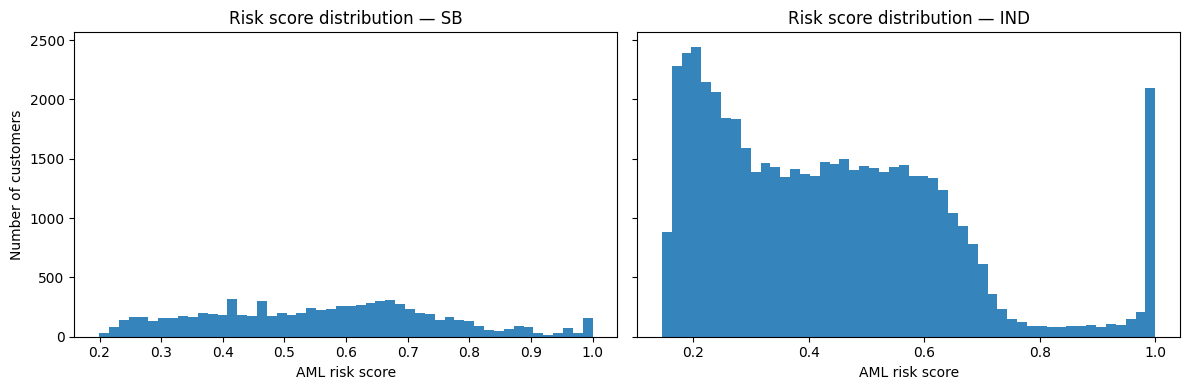

In [35]:
# 6.6) Top-5% high-risk summaries by customer_type (SB vs IND)
# Goal: provide AML-friendly review tables (ranked) + a simple visual.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Merge customer_type / cluster into scores (if not already)
meta_cols = [c for c in ["customer_id", "customer_type", "cluster"] if c in df.columns]
scores_view = scores.merge(df[meta_cols].drop_duplicates("customer_id"), on="customer_id", how="left")

def top_pct_table(scores_view, cust_type, pct=0.05, id_col="customer_id"):
    sub = scores_view[scores_view["customer_type"] == cust_type].copy()
    if len(sub) == 0:
        return None, None
    thr = sub["risk_score"].quantile(1 - pct)
    top = sub[sub["risk_score"] >= thr].sort_values("risk_score", ascending=False).copy()
    top.insert(0, "rank", np.arange(1, len(top) + 1))
    # Keep a compact set of columns for analysts
    cols = ["rank", id_col, "risk_score", "predicted_label"]
    if "cluster" in top.columns:
        cols.append("cluster")
    top = top[cols]
    return top, thr

top_sb, thr_sb = top_pct_table(scores_view, "SB", pct=0.05, id_col=ID_COL)
top_ind, thr_ind = top_pct_table(scores_view, "IND", pct=0.05, id_col=ID_COL)

def styled_table(df_in, title):
    if df_in is None:
        print(f"No rows found for {title}.")
        return
    print(title)
    # Visual highlight on risk score (works in Jupyter)
    display(
        df_in.style
            .format({"risk_score": "{:.6f}"})
            .background_gradient(subset=["risk_score"])
            .set_properties(**{"text-align": "center"})
    )

styled_table(top_sb, f"Top 5% high-risk customers — Small Business (SB) | threshold={thr_sb:.6f}" if top_sb is not None else "SB")
styled_table(top_ind, f"Top 5% high-risk customers — Individual (IND) | threshold={thr_ind:.6f}" if top_ind is not None else "IND")

# Quick operational summary
def summary_line(df_in, cust_type):
    if df_in is None:
        return None
    n = len(df_in)
    flagged = int(df_in["predicted_label"].sum())
    return pd.Series({
        "customer_type": cust_type,
        "top5pct_n": n,
        "flagged_in_top5pct": flagged,
        "flag_rate_in_top5pct": flagged / max(n, 1),
        "avg_risk_score_top5pct": df_in["risk_score"].mean()
    })

summ = pd.concat(
    [s for s in [summary_line(top_sb, "SB"), summary_line(top_ind, "IND")] if s is not None],
    axis=1
).T

if len(summ) > 0:
    display(summ)

# Plot: risk score distributions (side-by-side) + top-1% cut lines
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (ct, thr_ct) in zip(axes, [("SB", thr_sb), ("IND", thr_ind)]):
    sub = scores_view[scores_view["customer_type"] == ct]
    ax.hist(sub["risk_score"].values, bins=50, alpha=0.9)
    
    ax.set_title(f"Risk score distribution — {ct}")
    ax.set_xlabel("AML risk score")

axes[0].set_ylabel("Number of customers")
plt.tight_layout()
plt.show()


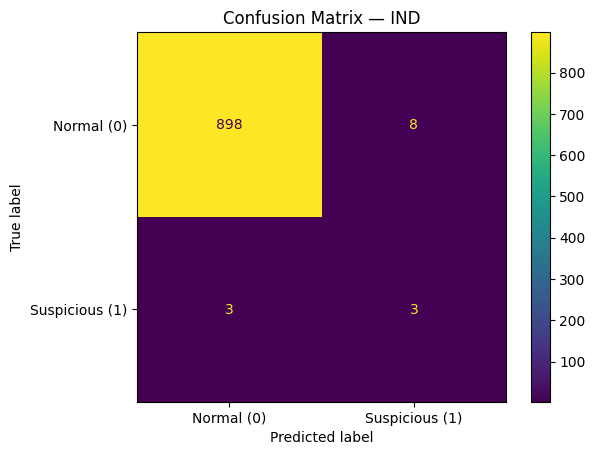

IND | TP=3 FP=8 FN=3 TN=898 | Recall=0.500 Precision=0.273 FPR=0.009


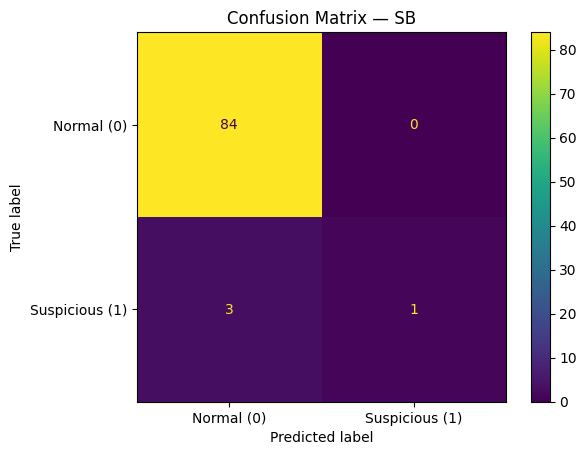

SB | TP=1 FP=0 FN=3 TN=84 | Recall=0.250 Precision=1.000 FPR=0.000


array([[84,  0],
       [ 3,  1]])

In [36]:
# 6.7) Confusion matrices by customer type (SB vs IND)
# Goal: show whether the model is better at detecting IND vs SB suspicious behavior.
# We compute confusion matrices on LABELED customers within each segment, using the GLOBAL threshold selected earlier.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Need: scores (contains risk_score, predicted_label), df (contains customer_type, label), and best_thr from threshold selection cell
best_thr = globals().get("chosen_t", None)
if best_thr is None:
    raise NameError("Global threshold (chosen_t) not found. Make sure the threshold-selection cell ran and defines chosen_t.")

eval_view = scores.merge(df[[ID_COL, "customer_type", LABEL_COL]], on=ID_COL, how="left")
eval_view = eval_view[eval_view[LABEL_COL].notna()].copy()
eval_view[LABEL_COL] = eval_view[LABEL_COL].astype(int)

def plot_cm_for_type(cust_type):
    sub = eval_view[eval_view["customer_type"] == cust_type].copy()
    if len(sub) == 0 or sub[LABEL_COL].nunique() < 2:
        print(f"{cust_type}: not enough labeled data (need both classes 0/1).")
        return None
    y_true = sub[LABEL_COL].values
    y_pred = (sub["risk_score"].values >= best_thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])

    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal (0)", "Suspicious (1)"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {cust_type}")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    recall = tp/(tp+fn+1e-12)
    fpr = fp/(fp+tn+1e-12)
    precision = tp/(tp+fp+1e-12)
    print(f"{cust_type} | TP={tp} FP={fp} FN={fn} TN={tn} | Recall={recall:.3f} Precision={precision:.3f} FPR={fpr:.3f}")
    return cm

plot_cm_for_type("IND")
plot_cm_for_type("SB")

In [37]:

# 7) Export in your required format (customer-level)
out = scores[[ID_COL, "predicted_label", "risk_score"]].copy()
out.to_csv("model_output.csv", index=False)
print("Saved model_output.csv with rows:", len(out))


Saved model_output.csv with rows: 61410
